# Using Historical Twitter Archive

### Scope

* It is possible to use social media and other media data searching for mentionds relevant to the OSCARS etc, as a proxy for public interest/engagement over time. You can use this as timeline to anchor and provide interpretation for patterns you discover in the award and other datasets you are working on.


### Background
* Between 2012 and 2022 a daily sample of 1% of Tweets posted to Twitter was collected by ASC and Wharton
* See https://research-it.wharton.upenn.edu/data/tweet-database/



---

### Purpose

* This notebook shows some steps for working with one kind of export from this data.

* The SQL query run was:
  ```

    SELECT year,
         month,
         day,
         CONCAT(month, '/', day, '/', year) AS date, 
         count(*) count
    FROM "transformed"
    WHERE lower(extended_full_text) LIKE '%oscars%'
            AND CONCAT(year, month, day) >= '20170120'
    GROUP BY  year, month, day
    ORDER BY  year, month, day
    
    ```

  which gives a daily count of the number of Tweets containing the string `oscars`


* Sample data file is in `data/example_twitter_timeline_OSCARS.csv`

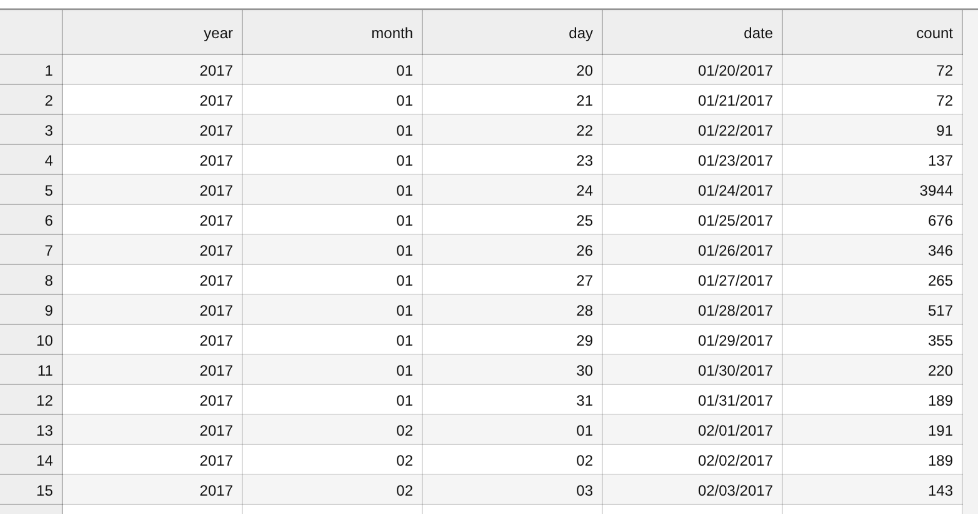{width=400}

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

### Load dataset

* Example time series for a search in tweet text for any occurrence of the sequence `oscars`
* Note this is too general a search but was used as an example to get a sample dataset

In [12]:
oscars_df = pd.read_csv('../data/example_twitter_timeline_OSCARS.csv')

* Convert the date `str` to a `datetime` object to facilitate date processing more easily in `pandas`

In [13]:
oscars_df['date_dt']=pd.to_datetime(oscars_df['date'], format='%m/%d/%Y')

### Some example plots

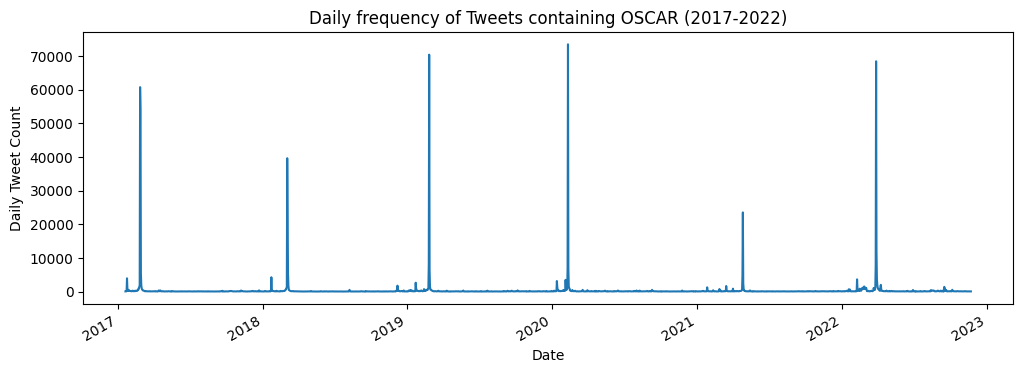

In [14]:
oscars_df.set_index('date_dt')['count'].plot(figsize=(12,4))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('Daily frequency of Tweets containing OSCAR (2017-2022)')
plt.show()

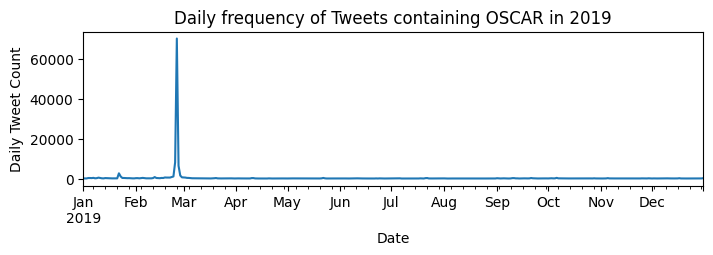

In [15]:
oscars_df.query('year==2019').set_index('date_dt')['count'].plot(figsize=(8,2))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('Daily frequency of Tweets containing OSCAR in 2019')
plt.show()

In [16]:
oscars_df.query('year==2017 and month==2')

,year,month,day,date,count,date_dt
12,2017,2,1,02/01/2017,191,2017-02-01
13,2017,2,2,02/02/2017,189,2017-02-02
14,2017,2,3,02/03/2017,143,2017-02-03
15,2017,2,4,02/04/2017,111,2017-02-04
16,2017,2,5,02/05/2017,118,2017-02-05
17,2017,2,6,02/06/2017,195,2017-02-06
18,2017,2,7,02/07/2017,277,2017-02-07
19,2017,2,8,02/08/2017,145,2017-02-08
20,2017,2,9,02/09/2017,139,2017-02-09
21,2017,2,10,02/10/2017,212,2017-02-10


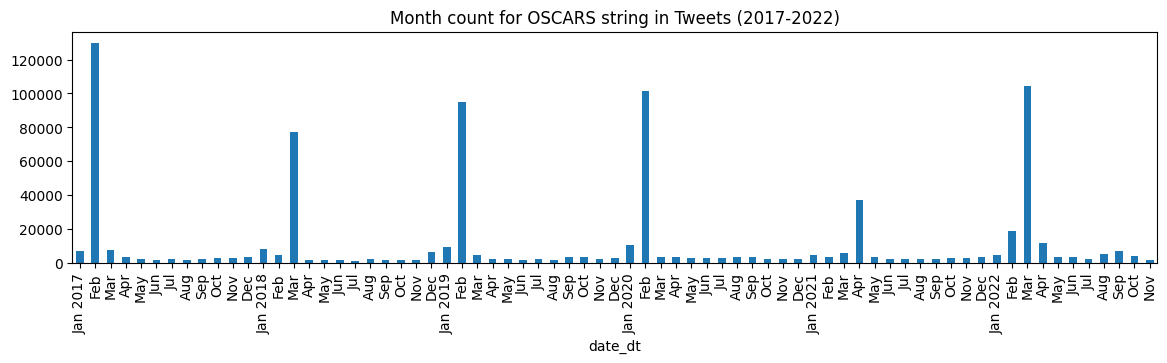

In [17]:
def line_format(label):
    """
    Convert time label to the format of pandas line plot
    """
    month = label.month_name()[:3]
    if month == 'Jan':
        month += f' {label.year}'
    return month


oscars_by_month = oscars_df.set_index('date_dt').resample('ME')['count'].sum()
    
ax=oscars_by_month.plot(kind='bar', figsize=(14,3))
ax.set_xticklabels(map(line_format, oscars_by_month.index))

plt.title('Month count for OSCARS string in Tweets (2017-2022)')
plt.show()


In [18]:
oscars_df.groupby(['year','month'])['count'].sum().reset_index()

,year,month,count
0,2017,1,6884
1,2017,2,130083
2,2017,3,7569
3,2017,4,3538
4,2017,5,2161
...,...,...,...
66,2022,7,2407
67,2022,8,4973
68,2022,9,6691
69,2022,10,3813


------

## Timeline for `oscarssowhite`

* Daily counts from Historical Twitter Database of `oscarssowhite`
* See `data/twitter/oscarssowhite_timeline_2015-2022.csv`

In [26]:
oscarssowhite = pd.read_csv('../data/oscarssowhite_timeline_2015-2022.csv')
oscarssowhite.shape

(709, 5)

* 709 days in the Twitter sample

In [27]:
oscarssowhite['date_dt']=pd.to_datetime(oscarssowhite['date'], format='%m/%d/%Y')

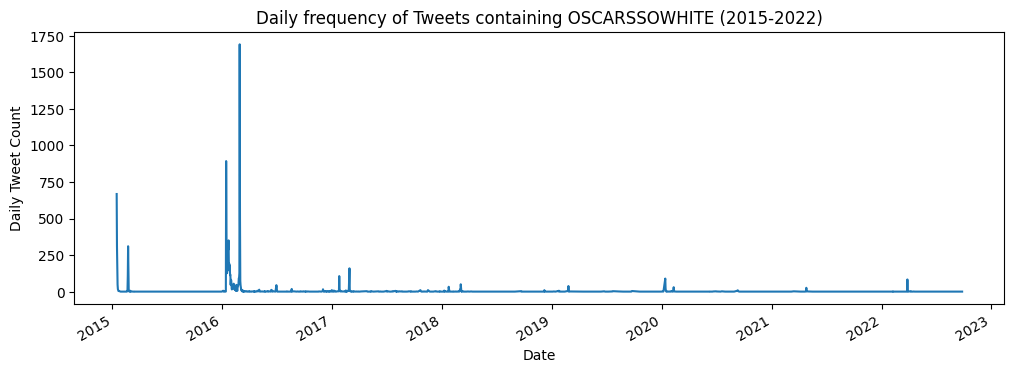

In [28]:
oscarssowhite.set_index('date_dt')['count'].plot(figsize=(12,4))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('Daily frequency of Tweets containing OSCARSSOWHITE (2015-2022)')
plt.show()

## Full tweet data

In [30]:
oscarssowhite_full_df = pd.read_csv('../data/oscarssowhite_tweets_2015-2022.csv')
oscarssowhite_full_df.shape

(11724, 63)

* Close to 12,000 tweets containing `oscarssowhite` from 2015-2022 in the Twitter Sample
* Note the sample is around 1% random sample each day - so frame numbers and use data with this in mind

#### Looking at fields recorded in database

In [31]:
oscarssowhite_full_df.columns

Index(['created_at', 'timestamp_ms', 'id', 'extended_full_text', 'user_id',
       'user_screen_name', 'user_name', 'user_followers_count',
       'user_location', 'user_created_at', 'user_friends_count',
       'user_statuses_count', 'user_verified', 'id_str', 'source', 'truncated',
       'in_reply_to_status_id', 'in_reply_to_status_id_str',
       'in_reply_to_user_id_str', 'in_reply_to_screen_name', 'contributors',
       'is_quote_status', 'quote_count', 'reply_count', 'retweet_count',
       'favorite_count', 'favorited', 'retweeted', 'filter_level', 'lang',
       'possibly_sensitive', 'withheld_copyright', 'place_name', 'text',
       'long', 'lat', 'quoted_status_id_str', 'place_country_code', 'rt_id',
       'rt_user_name', 'rt_extended_full_text', 'rt_text', 'rt_favorite_count',
       'rt_friends_count', 'rt_followers_count', 'rt_statuses_count',
       'rt_user_id', 'rt_retweet_count', 'rt_reply_count', 'rt_quote_count',
       'rt_user_verified', 'rt_user_location', 'rt_t

#### Look at random sample of 200 tweets looking at text

In [32]:
oscarssowhite_full_df.sample(200)['text'].values

<ArrowStringArray>
[                                       'Civil rights group on #OscarsSoWhite diversity plan: it's a "first step" --&gt; https://t.co/3bt1HKPrI1',
   '@Latashia146 #OscarsSoWhite? How about the 2016 Choices for a Democratic President\n#Democrats: #WhiterThanTheOscars https://t.co/qDQisiaI3W',
                                                                   'The latest Aviation Economics! https://t.co/zdIS3EKdUd #metoo #oscarssowhite',
                    'RT @tyriquex: Who actually thought comparing Whoopi Goldberg to Ursula was ok? Wow. #OscarsSoWhite  https://t.co/uQvytZL6Cl',
    'RT @msnbc: #OscarsSoWhite? Civil rights groups call for a boycott of the ceremony: http://t.co/3gMSvueGPg  (Reuters) http://t.co/YPhuXRbTA8',
                                            'RT @localtourkey: Oscar Winning Wardrobes Throughout History https://t.co/WePxfKVvrA #OscarsSoWhite',
     ''Aunt Viv' responds to Jada Pinkett Smith Oscars boycott #OscarsSoWhite #SillyAwardsNonsense 

## More Analysis

In [42]:
df = pd.read_csv('../data/oscarssowhite_timeline_2015-2022.csv')

NameError: name 'color_map' is not defined

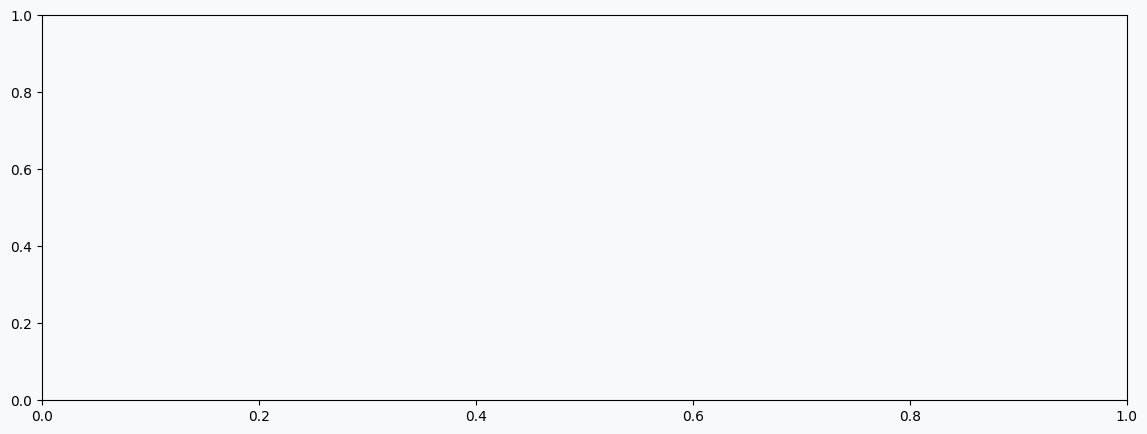

In [43]:
events = [
    ('2015-01-15', '#OscarsSoWhite\ncreated'),
    ('2015-02-22', '87th Oscars\nceremony'),
    ('2016-01-14', 'Academy\nnominations\nannounced'),
    ('2016-02-28', '88th Oscars\nceremony'),
    ('2017-02-26', '89th Oscars\n(La La Land/Moonlight)'),
]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for yr in sorted(df['year'].unique()):
    mask = df['year'] == yr
    ax.fill_between(df[mask].index, df[mask]['count'], alpha=0.3, color=color_map[yr])
    ax.plot(df[mask].index, df[mask]['count'], linewidth=1, color=color_map[yr], label=str(yr))

for date_str, label in events:
    dt = pd.to_datetime(date_str)
    val = df['count'].reindex([dt], method='nearest').iloc[0]
    ax.axvline(dt, color='#333', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.annotate(label, xy=(dt, val), xytext=(0, 12), textcoords='offset points',
                fontsize=7, ha='center', color='#333',
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.7))

ax.set_title('#OscarsSoWhite Daily Tweet Volume (2015–2022)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Tweet Count (1% sample)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.legend(title='Year', fontsize=8, loc='upper right', framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

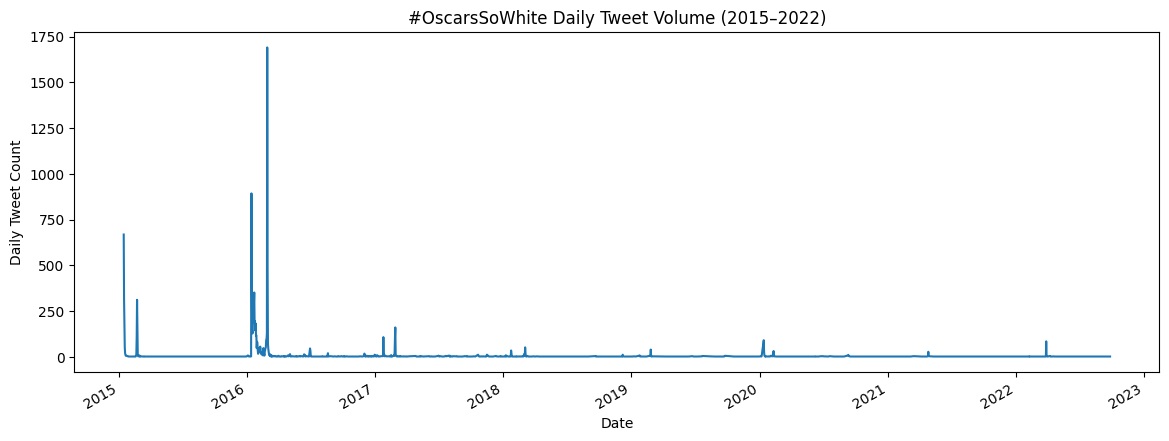

In [45]:
df['date_dt'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df.set_index('date_dt')['count'].plot(figsize=(14, 5))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('#OscarsSoWhite Daily Tweet Volume (2015–2022)')
plt.show()

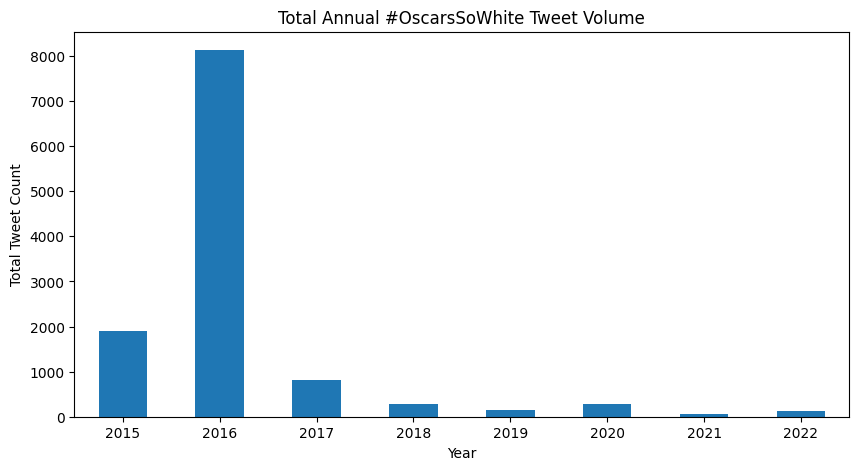

In [46]:
df.groupby('year')['count'].sum().plot(kind='bar', figsize=(10, 5))
plt.xlabel('Year')
plt.ylabel('Total Tweet Count')
plt.title('Total Annual #OscarsSoWhite Tweet Volume')
plt.xticks(rotation=0)
plt.show()